# MiniProject 1: Who wrote the disputed Federalist Papers?
**Author:** Ruhi Kabarwal
## Goal
Use word frequencies to tell apart two authors of the *Federalist Papers*, Alexander Hamilton and James Madison, and then apply what I learn to the 12 essays whose authorship is historically disputed.
The Federalist Papers are a good test case because they are a well-known authorship problem with a known answer. Mosteller and Wallace (1963) settled the question using function-word frequencies, so I can check whether a simple frequency analysis rediscovers their result.
## Data source
* Project Gutenberg, *The Federalist Papers* (ebook #1404): `http://www.gutenberg.org/ebooks/1404.txt.utf-8`
* This is one text file containing all 85 essays. I will split it into individual essays using the "FEDERALIST No. X" headers.
* Authorship labels (standard attribution):
  * Hamilton: 1, 6-9, 11-13, 15-17, 21-36, 59-61, 65-85
  * Madison: 10, 14, 37-48
  * Jay: 2-5, 64 (excluded from the comparison)
  * Joint (Hamilton with Madison): 18-20 (excluded from the comparison)
  * Disputed (Hamilton or Madison): 49-58, 62, 63
## Questions and how I will answer them
**Q1. Compare word frequencies between two works of a single author**
* Split Hamilton's known essays into two groups (early vs late, or two random halves) and compare their top-word frequencies.

**Q2. Compare word frequencies between works of two authors**
* Compare Hamilton's known essays against Madison's known essays.

**Q3. Are there words preferred by one author but used less by the other?**
* Focus on function words (articles, prepositions, conjunctions) since these reflect style rather than topic. All 85 essays are about the same subject, so content words will not separate the authors.
* Compute the frequency per 1,000 words of each candidate word for each author and rank by the size of the gap.
* Check the historically decisive words: Madison used "whilst" where Hamilton used "while," and Hamilton used "upon" far more often. I want to see whether these fall out of the data on their own.


## Step 1: Load the essays

All 85 essays are in one Project Gutenberg file, so I split it at each `FEDERALIST No. N` heading. Each essay's heading also names its author (the file even labels the disputed essays "MADISON"), so I keep only the essay text between *"To the People of the State of New York:"* and the signature *"PUBLIUS"*.

In [1]:
import re
import requests
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

%matplotlib inline

text = requests.get('http://www.gutenberg.org/ebooks/1404.txt.utf-8').text.replace('\r', '')
text = text.split('*** END OF THE PROJECT GUTENBERG')[0]   # drop the license at the end

# parts = [preface, '1', essay 1, '2', essay 2, ...]
parts = re.split(r'^FEDERALIST No\. (\d+)\n', text, flags=re.M)

essays = {}
for num, body in zip(parts[1::2], parts[2::2]):
    body = re.split(r'^To the People of the State of New York[:.]?\s*$', body, maxsplit=1, flags=re.M)[1]
    body = re.split(r'^PUBLIUS\.?\s*$', body, maxsplit=1, flags=re.M)[0]
    essays[int(num)] = body

print(len(essays), 'essays')

85 essays


## Step 2: Count words

* Jay's essays (2-5, 64) and the joint essays (18-20) are left out.
* I don't remove stop words: small words like *upon*, *by* and *on* are what show an author's habits.
* Hamilton wrote about three times as much as Madison, so I compare **rates per 1,000 words** instead of raw counts.

In [2]:
def numbers(*groups):
    return sorted(n for g in groups for n in g)

HAMILTON = numbers([1], range(6, 10), range(11, 14), range(15, 18), range(21, 37), range(59, 62), range(65, 86))
MADISON  = numbers([10, 14], range(37, 49))
DISPUTED = numbers(range(49, 59), [62, 63])

WORDS = {n: re.findall(r'[a-z]+', essays[n].lower()) for n in essays}

def rates(nums):
    """Frequency of every word per 1,000 words in a group of essays."""
    c = Counter(w for n in nums for w in WORDS[n])
    return pd.Series(c) * 1000 / sum(c.values())

pd.DataFrame({'essays': [len(HAMILTON), len(MADISON), len(DISPUTED)],
              'words': [sum(len(WORDS[n]) for n in g) for g in (HAMILTON, MADISON, DISPUTED)]},
             index=['Hamilton', 'Madison', 'Disputed'])

,essays,words
Hamilton,51,111322
Madison,14,38765
Disputed,12,24058


In [3]:
def plot_top_words(r_a, r_b, name_a, name_b, title, n=15):
    """Side-by-side bar charts of the n most frequent words in two groups."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 6))
    for ax, r, name in zip(axes, (r_a, r_b), (name_a, name_b)):
        top = r.sort_values(ascending=False).head(n)[::-1]   # barh draws from the bottom up
        ax.barh(top.index, top.values)
        ax.set_title(name)
        ax.set_xlabel('per 1,000 words')
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()
    shared = set(r_a.nlargest(n).index) & set(r_b.nlargest(n).index)
    print(f'{len(shared)} of the top {n} words are shared')

def preferred_words(r_a, r_b, name_a, name_b, n=8, min_rate=0.3):
    """Words group a uses much more often than group b, skipping rare words."""
    df = pd.DataFrame({name_a: r_a, name_b: r_b}).fillna(0)
    df = df[(df[name_a] + df[name_b]) / 2 >= min_rate]
    ratio = (df[name_a] + 0.1) / (df[name_b] + 0.1)   # +0.1 avoids dividing by zero
    return df.loc[ratio.sort_values(ascending=False).index[:n]].round(2)

## Q1. Two works by one author

Hamilton's early essays (1-36) compared with his later ones (59-85).

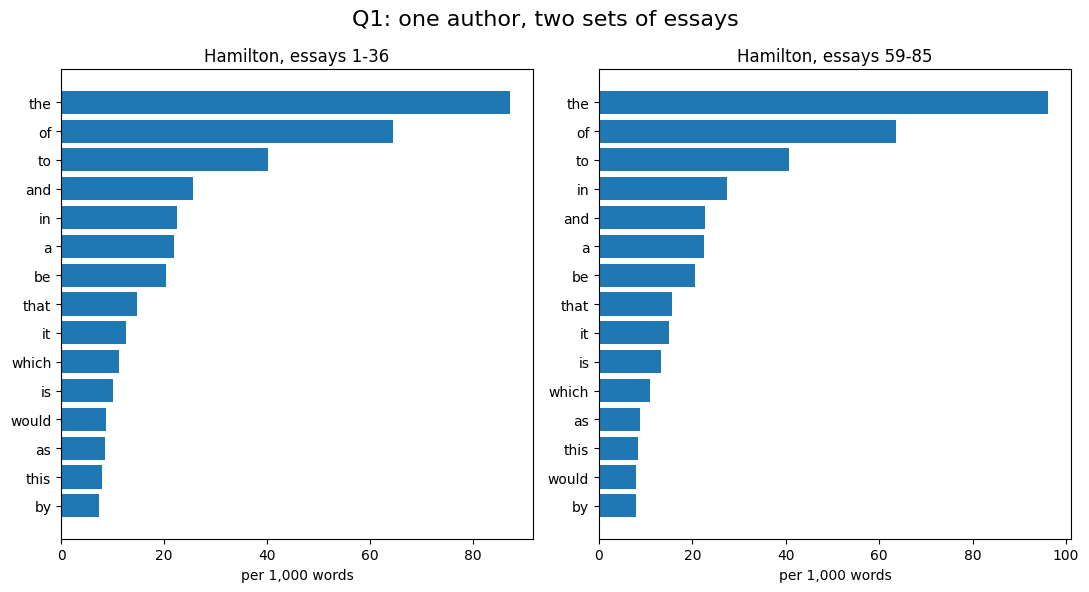

15 of the top 15 words are shared


In [4]:
H_EARLY = [n for n in HAMILTON if n <= 36]
H_LATE  = [n for n in HAMILTON if n >= 59]
r_early, r_late = rates(H_EARLY), rates(H_LATE)

plot_top_words(r_early, r_late, 'Hamilton, essays 1-36', 'Hamilton, essays 59-85',
               'Q1: one author, two sets of essays')

The top words are the same in both. The words that do differ are about the topic (taxes early on, the courts and the presidency later):

In [5]:
pd.concat([preferred_words(r_early, r_late, 'early', 'late', n=6),
           preferred_words(r_late, r_early, 'late', 'early', n=6)[['early', 'late']]],
          keys=['more in early essays', 'more in late essays'])

early  late
more in early essays taxation      0.71  0.04
                     confederacy   0.76  0.07
                     taxes         0.67  0.05
                     revenue       0.76  0.09
                     her           0.74  0.09
                     duties        0.74  0.09
more in late essays  president     0.00  1.73
                     jury          0.02  1.23
                     senate        0.09  1.91
                     office        0.02  0.98
                     trial         0.05  1.25
                     courts        0.16  1.89

## Q2. Works by two authors

Hamilton's essays compared with Madison's.

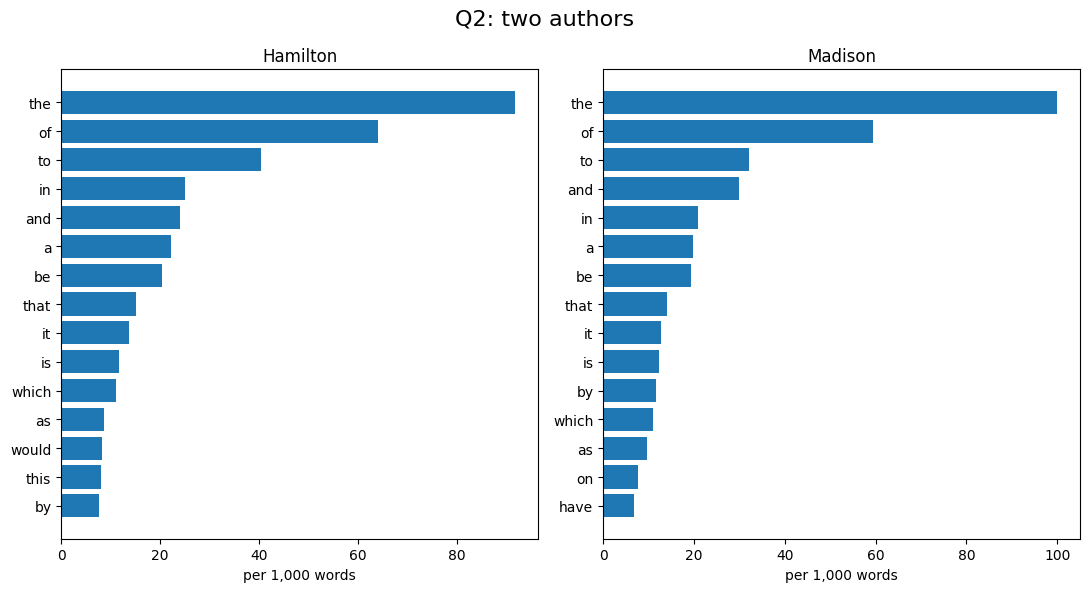

13 of the top 15 words are shared


In [6]:
r_ham, r_mad, r_dis = rates(HAMILTON), rates(MADISON), rates(DISPUTED)

plot_top_words(r_ham, r_mad, 'Hamilton', 'Madison', 'Q2: two authors')

Most of the top words are shared again, because both men wrote about the same subject in the same formal style. The few that differ (*this* and *would* for Hamilton, *on* and *have* for Madison) are small function words, which leads to Q3.

## Q3. Words one author prefers

The words with the biggest gap between the two authors (among words used at least 0.3 times per 1,000 words):

In [7]:
pd.concat([preferred_words(r_ham, r_mad, 'Hamilton', 'Madison'),
           preferred_words(r_mad, r_ham, 'Madison', 'Hamilton')[['Hamilton', 'Madison']]],
          keys=['Hamilton prefers', 'Madison prefers'])

Hamilton  Madison
Hamilton prefers upon               3.34     0.18
                 kind               0.68     0.03
                 courts             1.03     0.13
                 community          0.62     0.05
                 jury               0.63     0.08
                 there              3.40     0.85
                 court              0.80     0.21
                 thing              0.57     0.13
Madison prefers  department         0.17     1.44
                 confederation      0.21     1.42
                 departments        0.18     0.93
                 appointed          0.10     0.62
                 congress           0.35     1.52
                 powers             0.88     3.30
                 articles           0.25     1.01
                 fully              0.12     0.49

Many of these are topic words, but *upon* stands out: a function word that Hamilton uses about 18 times as often as Madison. Function words reflect habit rather than topic, so here are the most telling ones, with the disputed essays added for comparison:

In [8]:
FUNCTION_WORDS = ['upon', 'while', 'enough', 'there', 'would', 'by', 'on', 'also', 'although', 'whilst']

table = pd.DataFrame({'Hamilton': r_ham, 'Madison': r_mad, 'Disputed': r_dis}).reindex(FUNCTION_WORDS).fillna(0)
table['used more by'] = ['Hamilton' if h > m else 'Madison' for h, m in zip(table['Hamilton'], table['Madison'])]
table.round(2)

,Hamilton,Madison,Disputed,used more by
upon,3.34,0.18,0.12,Hamilton
while,0.32,0.00,0.00,Hamilton
enough,0.30,0.00,0.00,Hamilton
there,3.40,0.85,1.33,Hamilton
would,8.28,4.10,4.57,Hamilton
by,7.59,11.66,11.56,Madison
on,3.37,7.61,7.86,Madison
also,0.30,0.77,0.75,Madison
although,0.01,0.18,0.17,Madison
whilst,0.01,0.31,0.37,Madison


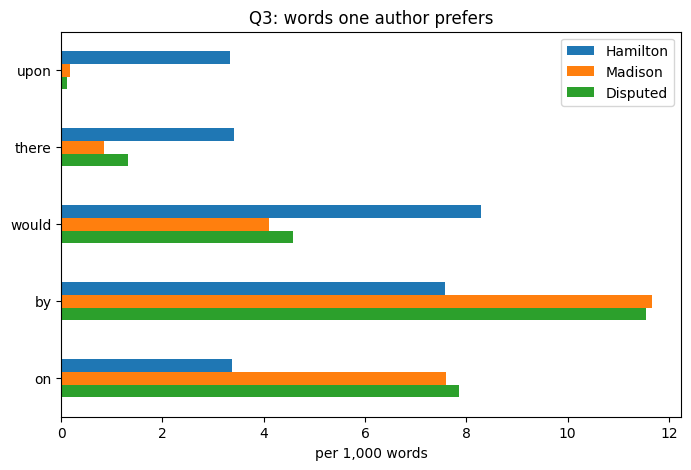

In [9]:
ax = table.loc[['upon', 'there', 'would', 'by', 'on'], ['Hamilton', 'Madison', 'Disputed']].plot.barh(figsize=(8, 5))
ax.invert_yaxis()
ax.set_xlabel('per 1,000 words')
ax.set_title('Q3: words one author prefers')
plt.show()

Hamilton prefers *upon*, *while*, *enough*, *there* and *would*. Madison prefers *by*, *on*, *also*, *although* and *whilst*. On every one of these words the disputed essays look like Madison, which agrees with Mosteller and Wallace (1963), who concluded that Madison wrote all 12.